# Import Packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Acess to google drive
from google.colab import drive
drive.mount('/content/drive')

# Load Data

Load data from the Github repository. Examples are below.

In [11]:
# Load data without column names
ExampleData = pd.read_csv('https://github.com/purduelamm/purdue_me597_iiot/blob/main/ml_tutorial/ML1/ExampleData?raw=true', sep=',', header=None)
ExampleData

,0,1,2,3
0,0.000000,0.016440,-0.014200,0.001433
1,0.000078,0.013822,-0.015707,0.001504
2,0.000156,0.019431,-0.016963,0.001433
3,0.000234,0.003726,-0.017248,0.001549
4,0.000313,0.022049,-0.009840,0.001864
...,...,...,...,...
2769,0.216330,0.077392,0.002404,0.003453
2770,0.216410,0.030276,0.003952,0.003498
2771,0.216480,0.017188,0.005504,0.003397
2772,0.216560,0.037754,-0.000108,0.003506


In [6]:
# Load data with column names
path = 'https://github.com/purduelamm/purdue_me597_iiot/blob/main/ml_tutorial/ML1/ExampleData?raw=true' # you can define data path as a variable first
ExampleData_withNames = pd.read_csv(path, sep=',',names=['time(s)', 'Acceleration(g)', 'Voltage(V)', 'Current(kA)'])
ExampleData_withNames

,time(s),Acceleration(g),Voltage(V),Current(kA)
0,0.000000,0.016440,-0.014200,0.001433
1,0.000078,0.013822,-0.015707,0.001504
2,0.000156,0.019431,-0.016963,0.001433
3,0.000234,0.003726,-0.017248,0.001549
4,0.000313,0.022049,-0.009840,0.001864
...,...,...,...,...
2769,0.216330,0.077392,0.002404,0.003453
2770,0.216410,0.030276,0.003952,0.003498
2771,0.216480,0.017188,0.005504,0.003397
2772,0.216560,0.037754,-0.000108,0.003506


**Tip**: You can try other ways to load data in Colab by referring to:

https://towardsdatascience.com/4-awesome-ways-of-loading-ml-data-in-google-colab-9a5264c61966

(4 Awesome Ways Of Loading ML Data In Google Colab)

# Data Handling

Define only sensor signals without time information

= Extract a part of ExampleData from second(1) column to last(3) column

In [12]:
SensorDataOnly = ExampleData.iloc[ :,1: ]
SensorDataOnly

,1,2,3
0,0.016440,-0.014200,0.001433
1,0.013822,-0.015707,0.001504
2,0.019431,-0.016963,0.001433
3,0.003726,-0.017248,0.001549
4,0.022049,-0.009840,0.001864
...,...,...,...
2769,0.077392,0.002404,0.003453
2770,0.030276,0.003952,0.003498
2771,0.017188,0.005504,0.003397
2772,0.037754,-0.000108,0.003506


Extract data from 0.01 seconds to 0.02 seconds

In [13]:
StartPoint = np.where(ExampleData.iloc[:,0].values == 0.01)[0][0]
EndPoint   = np.where(ExampleData.iloc[:,0].values == 0.02)[0][0]

StartPoint, EndPoint

(128, 256)

In [14]:
ExampleData_withNames.iloc[128:256+1,:]

,time(s),Acceleration(g),Voltage(V),Current(kA)
128,0.010000,-0.017962,-0.010766,-0.005784
129,0.010078,-0.094246,0.022769,0.001770
130,0.010156,-0.103970,-0.086215,-0.008154
131,0.010234,-0.103590,0.165990,0.005673
132,0.010313,-0.103220,-0.925800,-0.033911
...,...,...,...,...
252,0.019688,-0.213910,1.954200,3.787500
253,0.019766,-0.256910,1.879100,3.767100
254,0.019844,-0.278220,1.790100,3.738200
255,0.019922,-0.379560,1.695900,3.700200


In [15]:
SensorSignalOnly = ExampleData_withNames.iloc[StartPoint:EndPoint, :]
SensorSignalOnly

,time(s),Acceleration(g),Voltage(V),Current(kA)
128,0.010000,-0.017962,-0.010766,-0.005784
129,0.010078,-0.094246,0.022769,0.001770
130,0.010156,-0.103970,-0.086215,-0.008154
131,0.010234,-0.103590,0.165990,0.005673
132,0.010313,-0.103220,-0.925800,-0.033911
...,...,...,...,...
251,0.019609,-0.222880,2.025500,3.797800
252,0.019688,-0.213910,1.954200,3.787500
253,0.019766,-0.256910,1.879100,3.767100
254,0.019844,-0.278220,1.790100,3.738200


Transpose the matrix of data

In [16]:
TransposedData = SensorSignalOnly.T
TransposedData

,128,129,130,131,132,133,134,135,136,137,...,246,247,248,249,250,251,252,253,254,255
time(s),0.010000,0.010078,0.010156,0.010234,0.010313,0.010391,0.010469,0.010547,0.010625,0.010703,...,0.019219,0.019297,0.019375,0.019453,0.019531,0.019609,0.019688,0.019766,0.019844,0.019922
Acceleration(g),-0.017962,-0.094246,-0.103970,-0.103590,-0.103220,-0.104720,0.010083,-0.015719,-0.043390,0.172370,...,-0.379930,-0.569520,-0.685440,-0.523150,-0.356000,-0.222880,-0.213910,-0.256910,-0.278220,-0.379560
Voltage(V),-0.010766,0.022769,-0.086215,0.165990,-0.925800,-2.144800,-1.772900,-1.719100,-1.729600,-1.665700,...,2.400900,2.309700,2.233300,2.171600,2.110200,2.025500,1.954200,1.879100,1.790100,1.695900
Current(kA),-0.005784,0.001770,-0.008154,0.005673,-0.033911,-0.274470,-0.533520,-0.746910,-0.964190,-1.147400,...,3.702300,3.744900,3.775000,3.792700,3.799900,3.797800,3.787500,3.767100,3.738200,3.700200


# Save data

Save data as a file in your GoogleDrive

In [17]:
path = '/content/drive/MyDrive/Colab Notebooks/SavedFiles/Data_ML1_1.csv'
SensorSignalOnly.to_csv(path , sep=',' , index=None)

OSError: Cannot save file into a non-existent directory: '/content/drive/MyDrive/Colab Notebooks/SavedFiles'

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Load the data you just saved in your GoogleDrive

In [20]:
SensorSignalOnly_load = pd.read_csv(path)
SensorSignalOnly_load

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/SavedFiles/Data_ML1_1.csv'

# Plot Graphs

Graph options

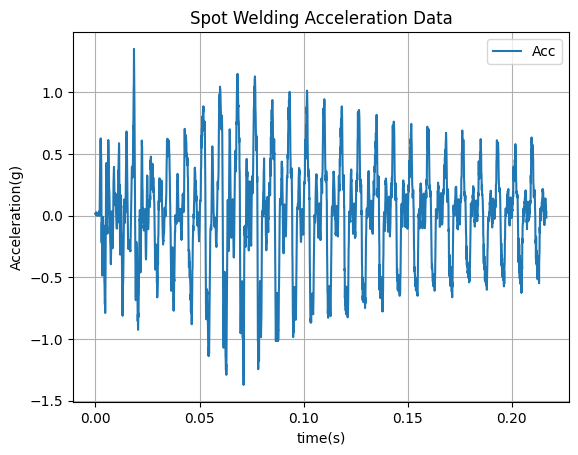

In [18]:
# ExampleData Column 0: time
# ExampleData Column 1: Acceleration signal

plt.plot(ExampleData.iloc[:,0], ExampleData.iloc[:,1])
plt.grid()
plt.xlabel('time(s)')
plt.ylabel('Acceleration(g)')
plt.title('Spot Welding Acceleration Data')
plt.legend(['Acc'], loc = 'upper right', fontsize=10)
# plt.xlim(0,0.02)
# plt.ylim(-1.5,1.5)
plt.show()

In [ ]:
# ExampleData Column 0: time
# ExampleData Column 2: Voltage signal

# ylabel: Voltage(V)
# title: Spot welding Voltage Data
# legend: Voltage (located at 'uppper center')

plt.plot()
plt.grid()
plt.xlabel()
plt.ylabel()
plt.title()
plt.legend()
plt.show()

In [ ]:
# ExampleData Column 0: time
# ExampleData Column 3: Current signal

# ylabel: Current(kA)
# title: Spot Welding Current Data
# legend: Current (located at 'best')

plt.plot()
plt.grid()
plt.xlabel()
plt.ylabel()
plt.title()
plt.legend()
plt.show()

Graph shapes

In [ ]:
plt.figure(figsize = (12,9))                                   # figure size
plt.plot(ExampleData.iloc[:100,0],ExampleData.iloc[:100,1],    # data (x, y)
         linestyle       = '-.',                               # line style
         linewidth       = 2.0,                                # line width
         color           = 'b',                                # line color
         marker          = 'o',                                # marker shape
         markersize      = 8,                                  # marker size
         markeredgecolor = 'g',                                # m.edge coler
         markeredgewidth = 1.5,                                # m.edge width
         markerfacecolor = 'r',                                # m.face color
         alpha           = 0.3)                                # opacity

plt.grid()
plt.xlabel('time(s)')
plt.ylabel('Acceleration(g)')
plt.title('Spot Welding Acceleration Data')
plt.legend(['Acc'], loc = 'best', fontsize=10)

Combine mulitple plots

In [ ]:
DataLength = 100   # Define plot length (~ DataLength/12800 seconds)

plt.figure(figsize = (10,5))
plt.plot(ExampleData.iloc[:DataLength,0],ExampleData.iloc[:DataLength,1])
plt.plot(ExampleData.iloc[:DataLength,0],ExampleData.iloc[:DataLength,2])
plt.plot(ExampleData.iloc[:DataLength,0],ExampleData.iloc[:DataLength,3])

plt.xlabel('time(s)')
plt.ylabel('Acceleration(g)')
plt.title('Spot Welding Acceleration Data')
plt.legend(['Acc', 'Voltage', 'Current'], loc = 'upper right', fontsize=10)

plt.grid()
plt.show()